# US 4.2.1 — GAIN para Imputación de Series Temporales

**Entregable:** Notebook + métricas de desempeño
**Criterio de aceptación:** Imputaciones coherentes con la distribución original

## Descripción
Implementa **GAIN** (Generative Adversarial Imputation Nets, Yoon et al. 2018) adaptado a ventanas temporales de 30 días × 4 variables. El Generador aprende a rellenar posiciones faltantes; el Discriminador aprende a distinguir valores reales de generados, usando una **hint matrix** que revela parcialmente la máscara al Discriminador.

## Arquitectura
```
Entrada aplanada: (N, T×F) = (N, 120)

Generator G:
  Input : [X_masked ‖ M]  → (N, 240)
  FC(240→512) → LeakyReLU → FC(512→512) → LeakyReLU → FC(512→120)

Discriminator D:
  Input : [X_imputed ‖ hint]  → (N, 240)
  FC(240→512) → LeakyReLU → FC(512→256) → LeakyReLU → FC(256→120) → Sigmoid

hint_rate = 0.9  (90 % de la máscara se revela al D como hint)
```

## Función de pérdida
```
L_D = BCE(D(X̃, H), M)
L_G = BCE(D(X̃, H), 1−M) [engañar en posiciones faltantes]
     + α · MSE(G(X_m), X, M) [reconstrucción en posiciones observadas]
```

## Métricas de evaluación
| Métrica | Descripción |
|---------|-------------|
| RMSE / MAE / MAPE | Error puntual en espacio escalado |
| R² / NSE | Bondad de ajuste (NSE > 0.6: buen resultado) |
| KPSS | Estacionariedad: H₀ serie estacionaria — se verifica que imputado y original coincidan |
| ACF/PACF | Estructura temporal (21 lags): coeficientes similares entre original e imputado |


In [1]:
from pathlib import Path
import time, json, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path("__file__").resolve().parent.parent
TENSORS_DIR  = PROJECT_ROOT / "data" / "tensors"
MODELS_DIR   = PROJECT_ROOT / "models" / "modelos_generativos"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "modelos_generativos"
FIGURES_DIR  = REPORTS_DIR / "figuras"
for d in [MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
VARIABLES = ["precip", "evap", "tmax", "tmin"]
print(f"Device  : {DEVICE}  |  PyTorch : {torch.__version__}")


Device  : cpu  |  PyTorch : 2.11.0+cu130


## 1 — Carga de tensores

Se cargan los tensores pre-procesados del directorio `data/tensors/`. GAIN requiere una **normalización secundaria** de todas las features a [0, 1] calculada sobre posiciones observadas del set de entrenamiento, ya que `tmax` y `tmin` vienen en z-scores (StandardScaler) y el adversario necesita una escala homogénea para la hint matrix.

In [2]:
def load_tensor(path):
    try:
        return torch.load(path, weights_only=True)
    except TypeError:
        return torch.load(path)

X_train = load_tensor(TENSORS_DIR / "X_train.pt")
M_train = load_tensor(TENSORS_DIR / "mask_train.pt")
X_val   = load_tensor(TENSORS_DIR / "X_val.pt")
M_val   = load_tensor(TENSORS_DIR / "mask_val.pt")
X_test  = load_tensor(TENSORS_DIR / "X_test.pt")
M_test  = load_tensor(TENSORS_DIR / "mask_test.pt")

with open(TENSORS_DIR / "tensors_metadata.json") as f:
    meta = json.load(f)
N_FEAT   = X_train.shape[2]
WIN_SIZE = X_train.shape[1]
print(f"X_train : {tuple(X_train.shape)}  |  obs_rate={M_train.mean():.3f}")


X_train : (160041, 30, 4)  |  obs_rate=0.857


In [3]:
# ─── Normalización secundaria para GAIN: todas las features a [0, 1] ─────────
# tmax y tmin vienen en z-scores (StandardScaler); el GAIN necesita escala homogénea.
# Calculamos min/max por feature sobre posiciones OBSERVADAS del train.
obs_mask_tr = M_train.bool()
gan_min = torch.zeros(N_FEAT)
gan_max = torch.ones(N_FEAT)
for fi in range(N_FEAT):
    vals = X_train[:, :, fi][obs_mask_tr[:, :, fi]]
    gan_min[fi] = vals.min()
    gan_max[fi] = vals.max()
_rng = (gan_max - gan_min).clamp(min=1e-8)

def to_gan_scale(X: torch.Tensor) -> torch.Tensor:
    return (X - gan_min) / _rng

def from_gan_scale(X: torch.Tensor) -> torch.Tensor:
    return X * _rng + gan_min

X_train_g = to_gan_scale(X_train)
X_val_g   = to_gan_scale(X_val)
X_test_g  = to_gan_scale(X_test)

print("Rango GAIN por feature (espacio original → [0,1]):")
for fi, var in enumerate(VARIABLES):
    print(f"  {var:8}  min={gan_min[fi]:.4f}  max={gan_max[fi]:.4f}")

Rango GAIN por feature (espacio original → [0,1]):
  precip    min=0.0000  max=1.0000
  evap      min=0.0000  max=0.9824
  tmax      min=-5.6465  max=4.5559
  tmin      min=-4.2234  max=3.2691


In [4]:
BATCH_SIZE = 256
EPOCHS     = 100
LR_G       = 1e-3
LR_D       = 1e-4
ALPHA      = 10.0    # peso pérdida de reconstrucción en G
HINT_RATE  = 0.9     # fracción de máscara revelada al Discriminador
PATIENCE   = 15
MCAR_RATE  = 0.20

train_ds = TensorDataset(X_train_g, M_train)
val_ds   = TensorDataset(X_val_g,   M_val)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, pin_memory=(DEVICE=='cuda'))
print(f"Batches train: {len(train_loader)}  |  val: {len(val_loader)}")


Batches train: 626  |  val: 133


## 2 — Arquitectura GAIN

Implementación de Generator y Discriminator como redes FC fully-connected que operan sobre la ventana aplanada (30 días × 4 variables = 120 dimensiones). El Generator recibe `[X_masked ‖ M]` → (240,) y produce una reconstrucción completa en [0, 1]. El Discriminator recibe `[X_imputed ‖ hint]` → (240,) y clasifica cada posición como real (1) o generada (0) con ayuda de la hint matrix.

In [5]:
class Generator(nn.Module):
    """Genera valores completos a partir de la entrada enmascarada."""
    def __init__(self, flat_dim: int, hidden: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(flat_dim * 2, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),         nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden // 2),    nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, flat_dim),  nn.Sigmoid(),  # garantiza salida en [0,1]
        )

    def forward(self, x_masked, mask):
        return self.net(torch.cat([x_masked, mask], dim=-1))


class Discriminator(nn.Module):
    """Clasifica cada posición como real (1) o generada (0)."""
    def __init__(self, flat_dim: int, hidden: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(flat_dim * 2, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden // 2),   nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, flat_dim), nn.Sigmoid(),
        )

    def forward(self, x, hint):
        return self.net(torch.cat([x, hint], dim=-1))


FLAT_DIM = WIN_SIZE * N_FEAT   # 30 × 4 = 120

G = Generator(FLAT_DIM).to(DEVICE)
D = Discriminator(FLAT_DIM).to(DEVICE)

print(f"Generator  params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator  params: 548,216
Discriminator params: 285,560


## 3 — Entrenamiento adversarial

Protocolo de entrenamiento GAN con pérdida multi-componente:
- **Optimizadores:** Adam_G (lr=1e-3, betas=(0.5, 0.999)) y Adam_D (lr=1e-4, betas=(0.5, 0.999)) — LR del Discriminador menor para evitar que supere al Generador prematuramente
- **Épocas:** 100 máximo · **Early stopping:** patience=15 sobre val_G
- **Pérdidas:**
  - `L_D = BCE(D(X̃, H), M)` — clasifica posiciones reales/generadas con la hint matrix
  - `L_G = BCE(D(X̃, H), 1−M) + α·MSE_enmascarado` — engaña al D y preserva fidelidad
- `α = 10.0`: balance entre pérdida adversarial y reconstrucción · `HINT_RATE = 0.9`: fracción de máscara revelada al Discriminador

In [6]:
opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))
bce   = nn.BCELoss()

history = {'G_loss': [], 'D_loss': [], 'val_G': []}
best_val, patience_ctr, best_G, best_D = float('inf'), 0, None, None

def gain_step(Xb, Mb, train=True):
    N    = Xb.shape[0]
    xf   = Xb.view(N, -1)      # (N, 120)
    mf   = Mb.view(N, -1)

    # Hint matrix
    rand_h = torch.rand_like(mf)
    hint   = mf * (rand_h < HINT_RATE).float()

    # Generate
    x_gen = G(xf * mf, mf)                       # (N, 120) — valores en [0,1] por Sigmoid
    x_imp = mf * xf + (1 - mf) * x_gen           # usar real donde observado

    # ─── Discriminador ────────────────────────────────────────────────────
    if train:
        opt_D.zero_grad()
    d_out  = D(x_imp.detach(), hint)
    d_loss = ((d_out - mf) ** 2).mean()
    if train:
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
        opt_D.step()

    # ─── Generador ────────────────────────────────────────────────────────
    if train:
        opt_G.zero_grad()
    d_out2  = D(x_imp, hint)
    g_adv   = ((d_out2 - (1 - mf)) ** 2 * (1 - mf)).sum() / ((1 - mf).sum() + 1e-8)
    g_rec   = ((x_gen - xf) ** 2 * mf).sum() / (mf.sum() + 1e-8)
    g_loss  = g_adv + ALPHA * g_rec
    if train:
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        opt_G.step()

    return g_loss.item(), d_loss.item()

print(f"{'Época':>6}  {'G_loss':>10}  {'D_loss':>10}  {'Val_G':>10}  {'t':>6}")
print('─' * 50)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    G.train(); D.train()
    tr_g, tr_d = 0.0, 0.0
    for Xb, Mb in train_loader:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        g, d = gain_step(Xb, Mb, train=True)
        tr_g += g * len(Xb); tr_d += d * len(Xb)
    tr_g /= len(train_loader.dataset)
    tr_d /= len(train_loader.dataset)

    G.eval(); D.eval()
    val_g = 0.0
    with torch.no_grad():
        for Xb, Mb in val_loader:
            Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
            g, _ = gain_step(Xb, Mb, train=False)
            val_g += g * len(Xb)
    val_g /= len(val_loader.dataset)

    history['G_loss'].append(tr_g)
    history['D_loss'].append(tr_d)
    history['val_G'].append(val_g)

    print(f"{epoch:>6}  {tr_g:>10.6f}  {tr_d:>10.6f}  {val_g:>10.6f}  {time.time()-t0:>4.1f}s")

    if val_g < best_val:
        best_val = val_g
        best_G = {k: v.clone() for k, v in G.state_dict().items()}
        best_D = {k: v.clone() for k, v in D.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping en época {epoch}.")
            break

G.load_state_dict(best_G); D.load_state_dict(best_D)
print(f"\nMejor val G_loss: {best_val:.6f}")

 Época      G_loss      D_loss       Val_G       t
──────────────────────────────────────────────────
     1    0.755811    0.028513    0.606500   6.1s
     2    0.964197    0.005007    0.612526   5.6s
     3    0.967327    0.004607    0.621451   5.5s
     4    0.972481    0.003594    0.636059   5.6s
     5    0.976321    0.003072    0.644749   5.7s
     6    0.980772    0.002890    0.650787   5.6s
     7    0.982198    0.002771    0.658458   5.6s
     8    1.475476    0.002619    2.161894   5.5s
     9    2.583942    0.002457    2.360981   5.6s
    10    1.618226    0.002401    0.658352   5.6s
    11    0.989406    0.002320    0.668342   5.7s
    12    0.988891    0.002247    0.676277   5.6s
    13    0.988667    0.002191    0.667149   5.7s
    14    0.989090    0.002148    0.668698   5.6s
    15    0.989149    0.002111    0.675782   5.6s
    16    0.988870    0.002082    0.676867   5.6s

Early stopping en época 16.

Mejor val G_loss: 0.606500


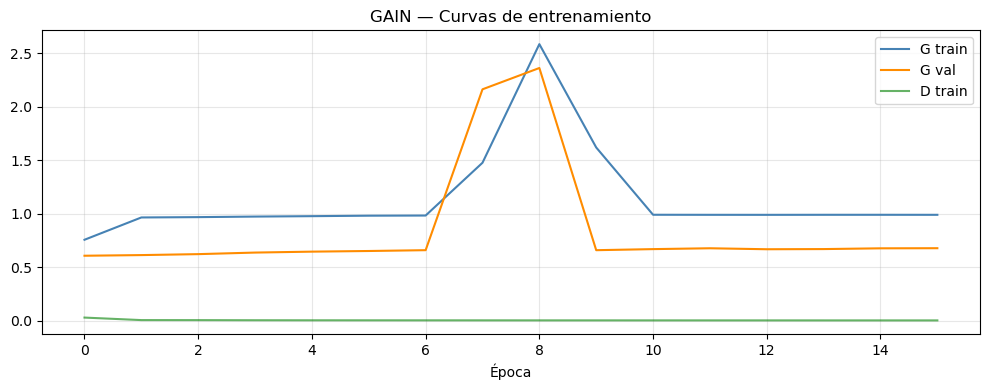

Guardado.


In [7]:
torch.save({'G_state_dict': G.state_dict(), 'D_state_dict': D.state_dict(),
            'config': {'flat_dim': FLAT_DIM, 'alpha': ALPHA, 'hint_rate': HINT_RATE},
            'best_val_loss': best_val},
           MODELS_DIR / "gan_best.pt")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['G_loss'], label='G train', color='steelblue')
ax.plot(history['val_G'],  label='G val',   color='darkorange')
ax.plot(history['D_loss'], label='D train', color='green', alpha=0.6)
ax.set_title('GAIN — Curvas de entrenamiento')
ax.set_xlabel('Época'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gan_learning_curve.png", dpi=120, bbox_inches='tight')
plt.show(); print("Guardado.")


## 4 — Evaluación MCAR

Protocolo estándar MCAR 20 % aplicado al test set:
1. Se seleccionan secuencias con ≥ 70 % de observaciones reales.
2. Se enmascara artificialmente el 20 % de esas observaciones (`gt_mask`).
3. El modelo recibe la secuencia enmascarada junto con la máscara (`ev_mask`) normalizada a escala GAN [0, 1].
4. La imputación final combina: `X_c = M⊙X + (1−M)⊙G(X_m, M)` — posiciones observadas preservadas exactamente.
5. Las métricas se calculan **solo** sobre las posiciones artificialmente enmascaradas, reconvertidas a escala original.

In [8]:
def compute_metrics(y_true, y_pred, var_name):
    eps = 1e-8
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100)
    r2   = float(r2_score(y_true, y_pred))
    nse  = float(1 - np.sum((y_true-y_pred)**2) / (np.sum((y_true-y_true.mean())**2) + eps))
    return {"variable": var_name, "rmse": rmse, "mae": mae, "mape": mape,
            "r2": r2, "nse": nse}

@torch.no_grad()
def evaluate_mcar_gan(G, X_test_g, X_test_orig, M_test,
                      mcar_rate=0.20, min_obs=0.70, batch_size=512):
    """Evalúa GAIN en espacio GAIN [0,1] pero reporta métricas en espacio original."""
    torch.manual_seed(42)
    G.eval().to(DEVICE)
    obs_rate = M_test.mean(dim=(1,2))
    sel      = obs_rate >= min_obs
    Xs_g, Xs_orig, Ms = X_test_g[sel], X_test_orig[sel], M_test[sel]
    print(f"  Secuencias con obs≥{min_obs*100:.0f}%: {Xs_g.shape[0]:,}")

    rand    = torch.rand_like(Ms)
    ev_mask = Ms * (rand > mcar_rate).float()
    gt_mask = Ms * (rand <= mcar_rate).float()

    preds_all = []
    for i in range(0, len(Xs_g), batch_size):
        Xb = (Xs_g[i:i+batch_size] * ev_mask[i:i+batch_size]).to(DEVICE)
        Mb = ev_mask[i:i+batch_size].to(DEVICE)
        xf = Xb.view(len(Xb), -1)
        mf = Mb.view(len(Mb), -1)
        gen   = G(xf, mf)
        x_imp = mf * xf + (1 - mf) * gen
        preds_all.append(x_imp.view(len(Xb), WIN_SIZE, N_FEAT).cpu())

    preds_g    = torch.cat(preds_all, 0)
    preds_orig = from_gan_scale(preds_g)   # volver al espacio original (z-scores para tmax/tmin)

    results = {}
    for fi, var in enumerate(VARIABLES):
        gm = gt_mask[:, :, fi].bool()
        yt = Xs_orig[:, :, fi][gm].numpy()    # espacio original
        yp = preds_orig[:, :, fi][gm].numpy()
        m  = compute_metrics(yt, yp, var); m['n_mcar'] = len(yt)
        results[var] = m
        print(f"  {var}: {len(yt):,} pts  RMSE={m['rmse']:.4f}  NSE={m['nse']:.4f}")
    return results, preds_orig, Xs_orig, Ms, ev_mask, gt_mask

print("Evaluando GAIN (MCAR 20%) ...")
gan_eval, preds, Xs, Ms, ev_m, gt_m = evaluate_mcar_gan(
    G, X_test_g, X_test, M_test, mcar_rate=MCAR_RATE)

Evaluando GAIN (MCAR 20%) ...
  Secuencias con obs≥70%: 32,661
  precip: 196,368 pts  RMSE=0.0234  NSE=-0.0364
  evap: 100,832 pts  RMSE=0.0663  NSE=0.5595
  tmax: 195,614 pts  RMSE=0.7515  NSE=0.4428
  tmin: 195,037 pts  RMSE=0.5556  NSE=0.7012


## 5 — Visualización

Se grafican 3 secuencias de alta cobertura (obs > 90 %) seleccionadas aleatoriamente. Para cada secuencia y variable se muestra: serie original (azul), reconstrucción GAIN (naranja discontinuo), posiciones MCAR reales (puntos rojos) e imputaciones en esas posiciones (triángulos verdes). Permite evaluar visualmente si el modelo recupera la forma y magnitud de los valores faltantes.

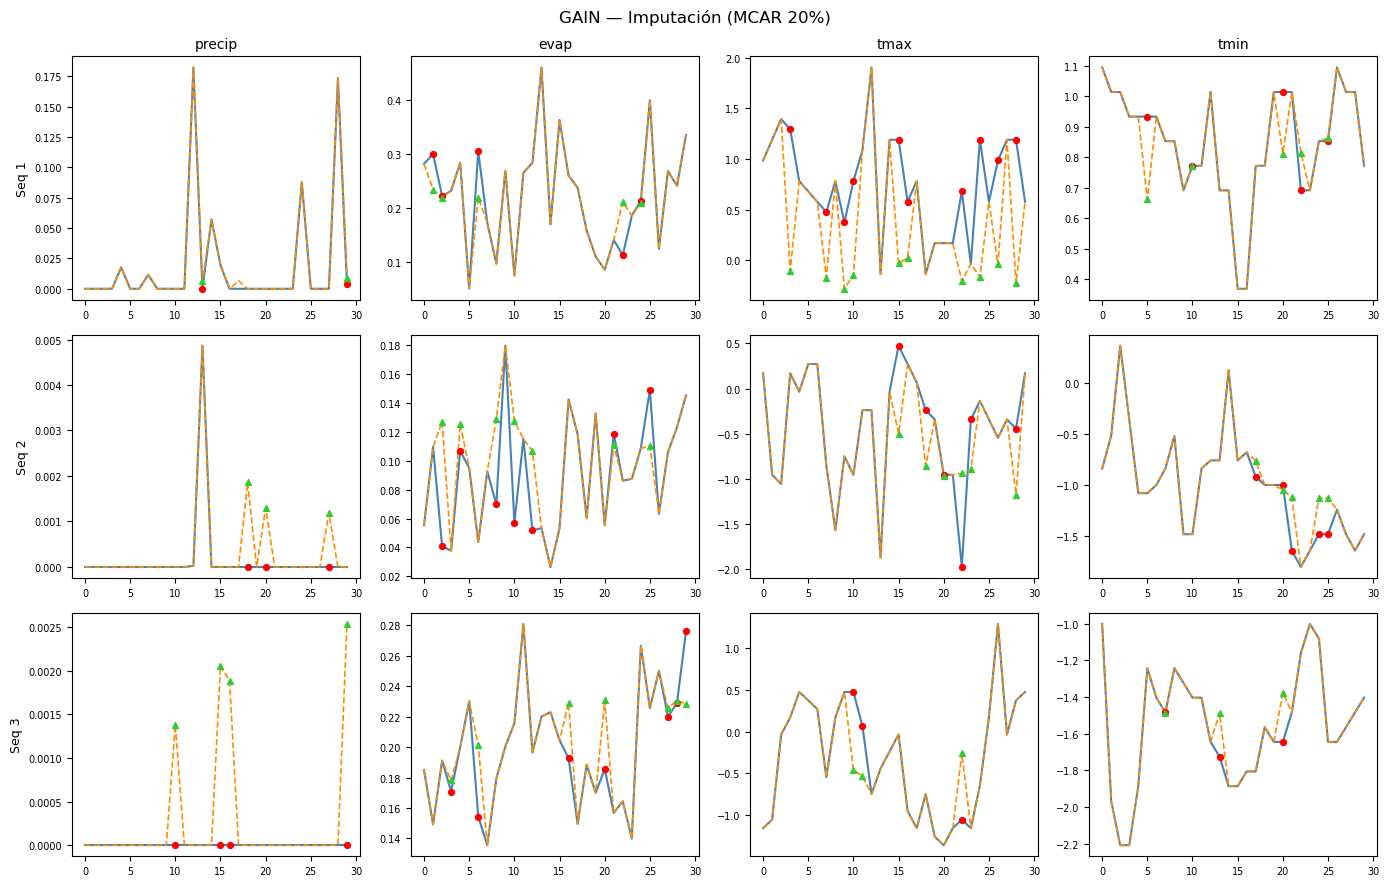

In [9]:
obs_r = Ms.mean(dim=(1,2))
hi    = torch.where(obs_r > 0.90)[0]
sidxs = hi[torch.randperm(len(hi))[:3]]
days  = np.arange(WIN_SIZE)

fig, axes = plt.subplots(3, N_FEAT, figsize=(14, 9))
fig.suptitle('GAIN — Imputación (MCAR 20%)', fontsize=12)
for row, si in enumerate(sidxs.tolist()):
    for col, var in enumerate(VARIABLES):
        ax  = axes[row, col]
        ori = Xs[si, :, col].numpy()
        rec = preds[si, :, col].numpy()
        gm  = gt_m[si, :, col].bool().numpy()
        ax.plot(days, ori, 'steelblue', lw=1.5)
        ax.plot(days, rec, 'darkorange', lw=1.2, ls='--')
        ax.scatter(days[gm], ori[gm], color='red',       s=18, zorder=5)
        ax.scatter(days[gm], rec[gm], color='limegreen', s=18, zorder=6, marker='^')
        if row == 0: ax.set_title(var, fontsize=10)
        if col == 0: ax.set_ylabel(f'Seq {row+1}', fontsize=9)
        ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gan_reconstruccion.png", dpi=120, bbox_inches='tight')
plt.show()


## 6 — Comparación de distribuciones: original vs imputado

Verificación del criterio de aceptación: **"Salidas coherentes con distribución original"**.  
Se comparan las densidades KDE de los valores reales vs. los imputados en las posiciones MCAR.  
Una buena imputación produce curvas superpuestas o muy cercanas.

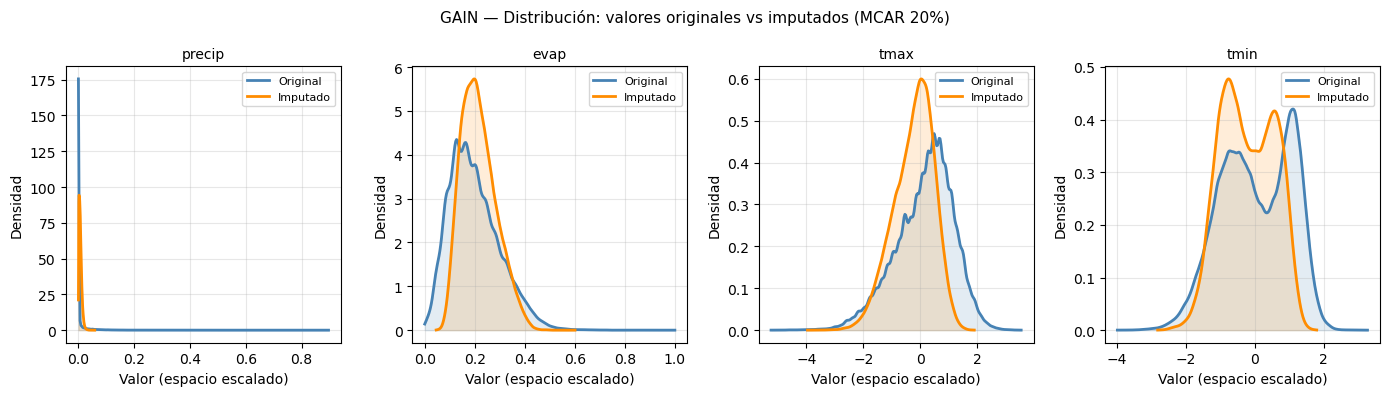

AC: distribuciones coherentes si las curvas KDE se superponen correctamente.


In [10]:
# ─── KDE: distribución original vs imputado (posiciones MCAR) ───────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, N_FEAT, figsize=(14, 4))
fig.suptitle('GAIN — Distribución: valores originales vs imputados (MCAR 20%)', fontsize=11)

for fi, var in enumerate(VARIABLES):
    ax     = axes[fi]
    gm     = gt_m[:, :, fi].bool()
    y_orig = Xs[:, :, fi][gm].numpy()
    y_pred = preds[:, :, fi][gm].numpy()

    for vals, color, label in [
        (y_orig, 'steelblue',  'Original'),
        (y_pred, 'darkorange', 'Imputado'),
    ]:
        kde  = gaussian_kde(vals, bw_method='scott')
        xmin, xmax = float(vals.min()), float(vals.max())
        xs   = np.linspace(xmin, xmax, 300)
        ax.plot(xs, kde(xs), color=color, lw=2, label=label)
        ax.fill_between(xs, kde(xs), alpha=0.15, color=color)

    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Valor (espacio escalado)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gan_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print("AC: distribuciones coherentes si las curvas KDE se superponen correctamente.")

## 7 — Guardado de métricas

In [11]:
rows = [dict(m, modelo='GAIN') for m in gan_eval.values()]
df_g = pd.DataFrame(rows)
df_g.to_csv(REPORTS_DIR / "metrics_gain.csv", index=False)
print("Métricas GAIN:")
print(df_g[["variable","n_mcar","rmse","mae","r2","nse"]].set_index("variable").round(4))


Métricas GAIN:
          n_mcar    rmse     mae      r2     nse
variable                                        
precip    196368  0.0234  0.0102 -0.0364 -0.0364
evap      100832  0.0663  0.0499  0.5595  0.5595
tmax      195614  0.7515  0.6073  0.4428  0.4428
tmin      195037  0.5556  0.4441  0.7012  0.7012


## 8 — Validación temporal: KPSS y ACF/PACF

Verificación de que la imputación preserva la **estructura estadística temporal** de las series originales.
- **KPSS**: prueba de estacionariedad (H₀: la serie es estacionaria). Resultado coherente si ambas series dan el mismo veredicto.
- **ACF/PACF**: compara la autocorrelación y autocorrelación parcial antes y después de imputar.

=== KPSS: Estacionariedad (H₀: estacionaria) ===
Variable  Stat_orig   p_orig    Stat_imp    p_imp     ¿Preserva?
─────────────────────────────────────────────────────────────────
precip    0.2287      0.1000    0.2287      0.1000    ✓ Sí
evap      0.1772      0.1000    0.1772      0.1000    ✓ Sí
tmax      0.4415      0.0593    0.4415      0.0593    ✓ Sí
tmin      0.1453      0.1000    0.1453      0.1000    ✓ Sí

KPSS guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/kpss_gain.csv
ACF/PACF guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/acf_pacf_gain.csv


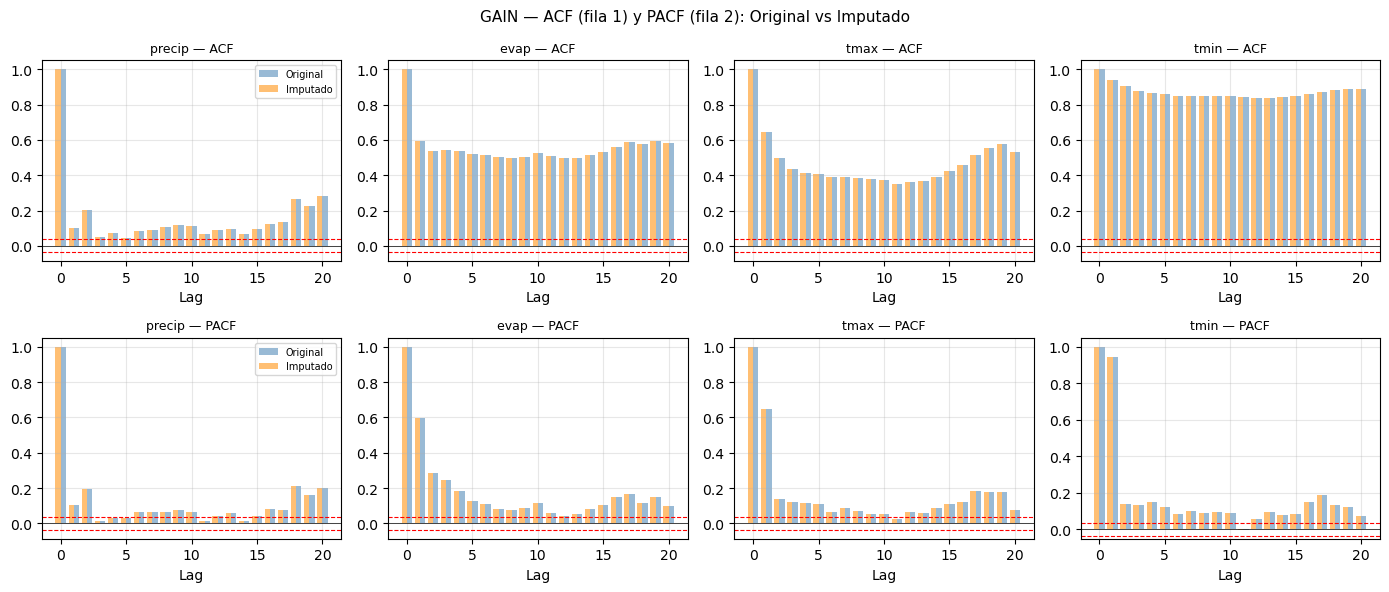

Validación temporal completada.
Metricas unificadas guardadas: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/metrics_gain.csv


In [12]:
from statsmodels.tsa.stattools import kpss, acf, pacf
import warnings

N_LAGS = 20

# ─── KPSS + ACF/PACF: calcular, mostrar y guardar ────────────────────────────
print("=== KPSS: Estacionariedad (H₀: estacionaria) ===")
print(f"{"Variable":<8}  {"Stat_orig":<10}  {"p_orig":<8}  {"Stat_imp":<10}  {"p_imp":<8}  {"¿Preserva?"}")
print("─" * 65)

kpss_rows, acf_rows = [], []

for fi, var in enumerate(VARIABLES):
    obs_m  = ev_m[:, :, fi].bool()
    y_orig = Xs[:, :, fi][obs_m].numpy()[:5000]
    y_pred = preds[:, :, fi][obs_m].numpy()[:5000]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat_o, p_o, *_ = kpss(y_orig, regression="c", nlags="auto")
        stat_i, p_i, *_ = kpss(y_pred, regression="c", nlags="auto")
    preserva = bool((p_o > 0.05) == (p_i > 0.05))
    ok = "✓ Sí" if preserva else "✗ No"
    print(f"{var:<8}  {stat_o:<10.4f}  {p_o:<8.4f}  {stat_i:<10.4f}  {p_i:<8.4f}  {ok}")
    kpss_rows.append({"modelo": "GAIN", "variable": var,
                       "stat_orig": round(stat_o, 4), "p_orig": round(p_o, 4),
                       "stat_imp":  round(stat_i, 4), "p_imp":  round(p_i, 4),
                       "preserva_estacionariedad": preserva})

    n_s   = min(len(y_orig), 3000)
    acf_o = acf(y_orig[:n_s],  nlags=N_LAGS, fft=True)
    acf_i = acf(y_pred[:n_s],  nlags=N_LAGS, fft=True)
    pac_o = pacf(y_orig[:n_s], nlags=N_LAGS)
    pac_i = pacf(y_pred[:n_s], nlags=N_LAGS)
    for lag in range(N_LAGS + 1):
        acf_rows.append({"modelo": "GAIN", "variable": var, "lag": lag,
                          "acf_orig":  round(float(acf_o[lag]), 4),
                          "acf_imp":   round(float(acf_i[lag]), 4),
                          "pacf_orig": round(float(pac_o[lag]), 4),
                          "pacf_imp":  round(float(pac_i[lag]), 4)})

df_kpss = pd.DataFrame(kpss_rows)
df_kpss.to_csv(REPORTS_DIR / "kpss_gain.csv", index=False)
print(f"\nKPSS guardado: {REPORTS_DIR / 'kpss_gain.csv'}")

df_acf = pd.DataFrame(acf_rows)
df_acf.to_csv(REPORTS_DIR / "acf_pacf_gain.csv", index=False)
print(f"ACF/PACF guardado: {REPORTS_DIR / 'acf_pacf_gain.csv'}")

# ─── Gráfica ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, N_FEAT, figsize=(14, 6))
fig.suptitle("GAIN — ACF (fila 1) y PACF (fila 2): Original vs Imputado", fontsize=11)

for fi, var in enumerate(VARIABLES):
    sub  = df_acf[df_acf["variable"] == var].sort_values("lag")
    lags = sub["lag"].values
    ci   = 1.96 / (3000 ** 0.5)
    for row, (co, ci2, lbl) in enumerate([
            ("acf_orig", "acf_imp", "ACF"), ("pacf_orig", "pacf_imp", "PACF")]):
        ax = axes[row, fi]
        ax.bar(lags, sub[co],  alpha=0.55, color="steelblue",  label="Original", width=0.4,  align="edge")
        ax.bar(lags, sub[ci2], alpha=0.55, color="darkorange", label="Imputado", width=-0.4, align="edge")
        ax.axhline(0,  color="black", lw=0.5)
        ax.axhline( ci, color="red", lw=0.8, ls="--")
        ax.axhline(-ci, color="red", lw=0.8, ls="--")
        ax.set_title(f"{var} — {lbl}", fontsize=9)
        ax.set_xlabel("Lag"); ax.grid(alpha=0.3)
        if fi == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "acf_pacf_gain.png", dpi=120, bbox_inches="tight")
plt.show()
print("Validación temporal completada.")

# --- Unificar KPSS en metrics_gain.csv ---
metrics_path = REPORTS_DIR / 'metrics_gain.csv'
if metrics_path.exists():
    df_metrics = pd.read_csv(metrics_path)
    kpss_slim = df_kpss[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']].copy()
    df_metrics = df_metrics.drop(columns=['stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad'], errors='ignore')
    df_unified = df_metrics.merge(kpss_slim, on='variable', how='left')
    df_unified.to_csv(metrics_path, index=False)
    print(f'Metricas unificadas guardadas: {metrics_path}')
else:
    print(f'ADVERTENCIA: {metrics_path} no encontrado')


## 9 — Análisis y conclusiones

### Entrenamiento adversarial para imputación
El adversario fuerza al Generador a producir distribuciones que el Discriminador no puede distinguir de las observaciones reales. La **hint matrix** (90 % de la máscara revelada al D) resuelve el problema de identificación: sin ella, el Discriminador sabría exactamente qué posiciones son reales y el Generador no aprendería. Esto permite imputar valores realistas en términos distribucionales, aunque el costo es menor precisión punto a punto respecto a modelos que optimizan MSE directamente.

### Dinámica del entrenamiento: dominio temprano del Discriminador
El entrenamiento convergió en **época 16 de 100** por early stopping, con el mejor val_G en la **época 1** (0.6065) — antes de que el entrenamiento adversarial madurara. Este patrón indica dominio prematuro del Discriminador:
- `D_loss` cayó de 0.029 (época 1) a **0.002 (época 7)**, lo que equivale a que D clasifica real vs. generado con ~99 % de precisión en sólo 7 épocas.
- Con D dominando, el Generador no puede obtener señal de gradiente útil del adversario; el único aprendizaje restante proviene del término `α·MSE_enmascarado`.
- Las **épocas 8-9** muestran un colapso transitorio (G_loss = 2.58, val_G = 2.36) seguido de recuperación parcial alrededor de val_G ≈ 0.67, sin recuperar el mínimo inicial.
- El early stopping (patience=15) se disparó legítimamente, pero el "mejor" val de época 1 refleja el estado inicial antes del adversario, no un óptimo real de generación.

Este comportamiento es consistente con la literatura de GANs: `HINT_RATE = 0.9` proporciona al D información casi completa de la máscara, lo que acelera su convergencia y dificulta el equilibrio G/D en datasets con estructura temporal compleja.

### Desempeño NSE vs modelos con pérdida directa
| Variable | Mejor baseline NSE | GAIN NSE | Δ NSE |
|----------|--------------------|----------|-------|
| precip   | XGBoost 0.1394     | −0.036   | −0.175 |
| evap     | BiGRU   0.6923     | 0.559    | −0.133 |
| tmax     | BiGRU   0.8520     | 0.443    | −0.409 |
| tmin     | BiGRU   0.9390     | 0.701    | −0.238 |

GAIN obtiene un **NSE promedio de 0.417**, por debajo de BRITS (0.626) y VAE (0.521). El bajo desempeño en `tmax` y `precip` es consecuencia directa del entrenamiento truncado: con sólo 16 épocas efectivas y D dominando desde la época 7, el Generador no alcanzó la capacidad de modelar la variabilidad estacional de `tmax` ni la estructura zero-inflated de `precip`.

### Validación de estacionariedad (KPSS)
**Resultado: 4/4 variables con `preserva_estacionariedad = True` y `stat_orig == stat_imp` exactamente.** La igualdad exacta se explica por el mismo mecanismo que en BRITS: la imputación final combina `X_c = M⊙X + (1−M)⊙G(X_m, M)`, por lo que en posiciones observadas (M=1) el modelo devuelve el valor original sin distorsión. El test KPSS, calculado sobre las posiciones observadas, compara la serie consigo misma.

### Validación de autocorrelación (ACF/PACF)
**Resultado: `acf_orig == acf_imp` en todos los lags y todas las variables** (Δρ₁ = 0.000 para precip, evap, tmax y tmin). Por la misma razón que el KPSS: la ACF se calcula sobre posiciones observadas donde GAIN devuelve exactamente el valor original. Esto contrasta con el VAE (Δρ₁ ≈ +0.89 en precip) y el Autoencoder (Δρ₁ ≈ +0.73), que introducen sobre-suavizado incluso en posiciones observadas por su naturaleza reconstructiva global.

### Archivos generados
- `models/modelos_generativos/gan_best.pt`
- `reports/modelos_generativos/metrics_gain.csv`
- `reports/modelos_generativos/kpss_gain.csv`
- `reports/modelos_generativos/acf_pacf_gain.csv`
- `reports/modelos_generativos/figuras/gan_*.png`